In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             confusion_matrix, classification_report)

In [2]:
df = pd.read_csv("train.csv")

print("Shape:", df.shape)
print("\nЗагальна інформація:")
display(df.info())

print("\nПропущені значення:")
print(df.isnull().sum())

display(df.head())

Shape: (891, 12)

Загальна інформація:
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


None


Пропущені значення:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
if 'Cabin' in df.columns: df = df.drop(columns=['Cabin'])

print("Пропущені значення після обробки:")
print(df.isnull().sum())

Пропущені значення після обробки:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


In [4]:
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

df['Embarked'] = df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

print("Типи даних після перетворення:")
print(df.dtypes)
display(df.head())

Типи даних після перетворення:
PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex              int64
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Embarked         int64
dtype: object


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,1
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,0
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,0


In [5]:
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
target = 'Survived'

X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Розмір навчальної вибірки:", X_train.shape)
print("Розмір тестової вибірки:", X_test.shape)
print("\nБаланс класів у навчальній вибірці:")
print(y_train.value_counts())

Розмір навчальної вибірки: (712, 7)
Розмір тестової вибірки: (179, 7)

Баланс класів у навчальній вибірці:
Survived
0    444
1    268
Name: count, dtype: int64


In [6]:
model = DecisionTreeClassifier(max_depth=5, random_state=42)
model.fit(X_train, y_train)

print("Модель навчена успішно")

Модель навчена успішно


In [7]:
y_pred = model.predict(X_test)

print("Глибина дерева:", model.get_depth())
print("Кількість вузлів:", model.get_n_leaves())
print("\nПерші 10 передбачень:", y_pred[:10])
print("Реальні значення:    ", y_test.values[:10])

Глибина дерева: 5
Кількість вузлів: 24

Перші 10 передбачень: [0 0 0 1 1 1 1 0 1 1]
Реальні значення:     [1 0 0 1 1 1 1 0 1 1]


In [8]:
accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)

print("Метрики якості класифікації:")
print(f"  Accuracy:  {accuracy:.3f}")
print(f"  Precision: {precision:.3f}")
print(f"  Recall:    {recall:.3f}")
print(f"  F1-score:  {f1:.3f}")

print("\nДетальний звіт:")
print(classification_report(y_test, y_pred,
      target_names=['Не вижив (0)', 'Вижив (1)']))

Метрики якості класифікації:
  Accuracy:  0.799
  Precision: 0.828
  Recall:    0.649
  F1-score:  0.727

Детальний звіт:
              precision    recall  f1-score   support

Не вижив (0)       0.79      0.90      0.84       105
   Вижив (1)       0.83      0.65      0.73        74

    accuracy                           0.80       179
   macro avg       0.81      0.78      0.78       179
weighted avg       0.80      0.80      0.79       179



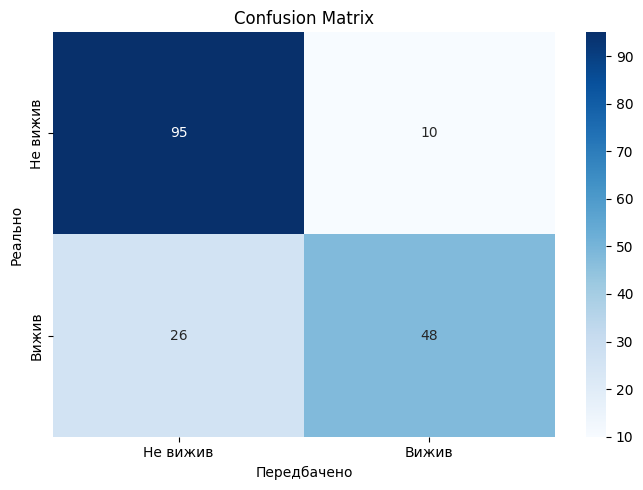


True Negative  (TN): 95 — правильно передбачено 'не вижив'
False Positive (FP): 10 — помилково передбачено 'вижив'
False Negative (FN): 26 — помилково передбачено 'не вижив'
True Positive  (TP): 48 — правильно передбачено 'вижив'


In [9]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm, annot=True, fmt='d',
    cmap='Blues',
    xticklabels=['Не вижив', 'Вижив'],
    yticklabels=['Не вижив', 'Вижив']
)
plt.xlabel("Передбачено")
plt.ylabel("Реально")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

print(f"\nTrue Negative  (TN): {cm[0][0]} — правильно передбачено 'не вижив'")
print(f"False Positive (FP): {cm[0][1]} — помилково передбачено 'вижив'")
print(f"False Negative (FN): {cm[1][0]} — помилково передбачено 'не вижив'")
print(f"True Positive  (TP): {cm[1][1]} — правильно передбачено 'вижив'")

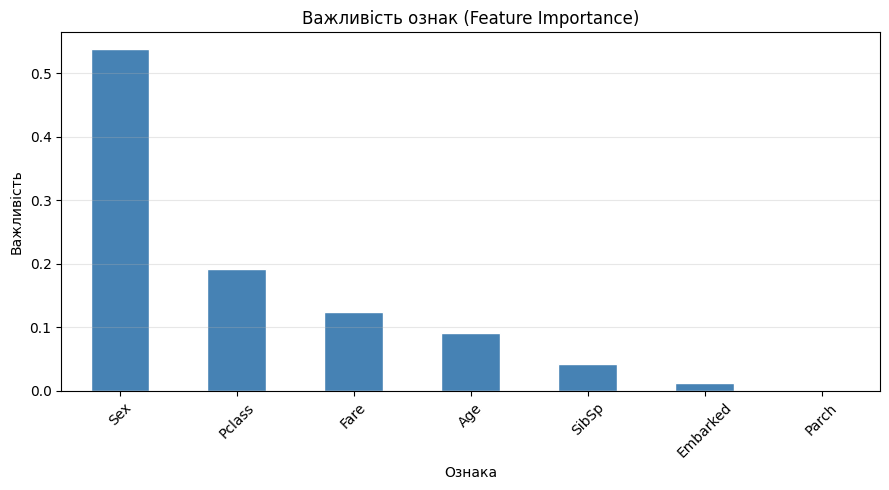


Важливість ознак:
Sex         0.537435
Pclass      0.191388
Fare        0.124937
Age         0.090645
SibSp       0.042707
Embarked    0.012888
Parch       0.000000
dtype: float64


In [10]:
importance = pd.Series(
    model.feature_importances_,
    index=features
).sort_values(ascending=False)

plt.figure(figsize=(9, 5))
importance.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title("Важливість ознак (Feature Importance)")
plt.ylabel("Важливість")
plt.xlabel("Ознака")
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("\nВажливість ознак:")
print(importance)

In [11]:
print("Інтерпретація важливості ознак:\n")
for feat, imp in importance.items():
    if imp > 0.15:
        level = "Дуже висока"
    elif imp > 0.08:
        level = "Висока"
    elif imp > 0.03:
        level = "Середня"
    else:
        level = "Низька"
    print(f"  {feat:<12} {imp:.3f}  — {level}")

Інтерпретація важливості ознак:

  Sex          0.537  — Дуже висока
  Pclass       0.191  — Дуже висока
  Fare         0.125  — Висока
  Age          0.091  — Висока
  SibSp        0.043  — Середня
  Embarked     0.013  — Низька
  Parch        0.000  — Низька


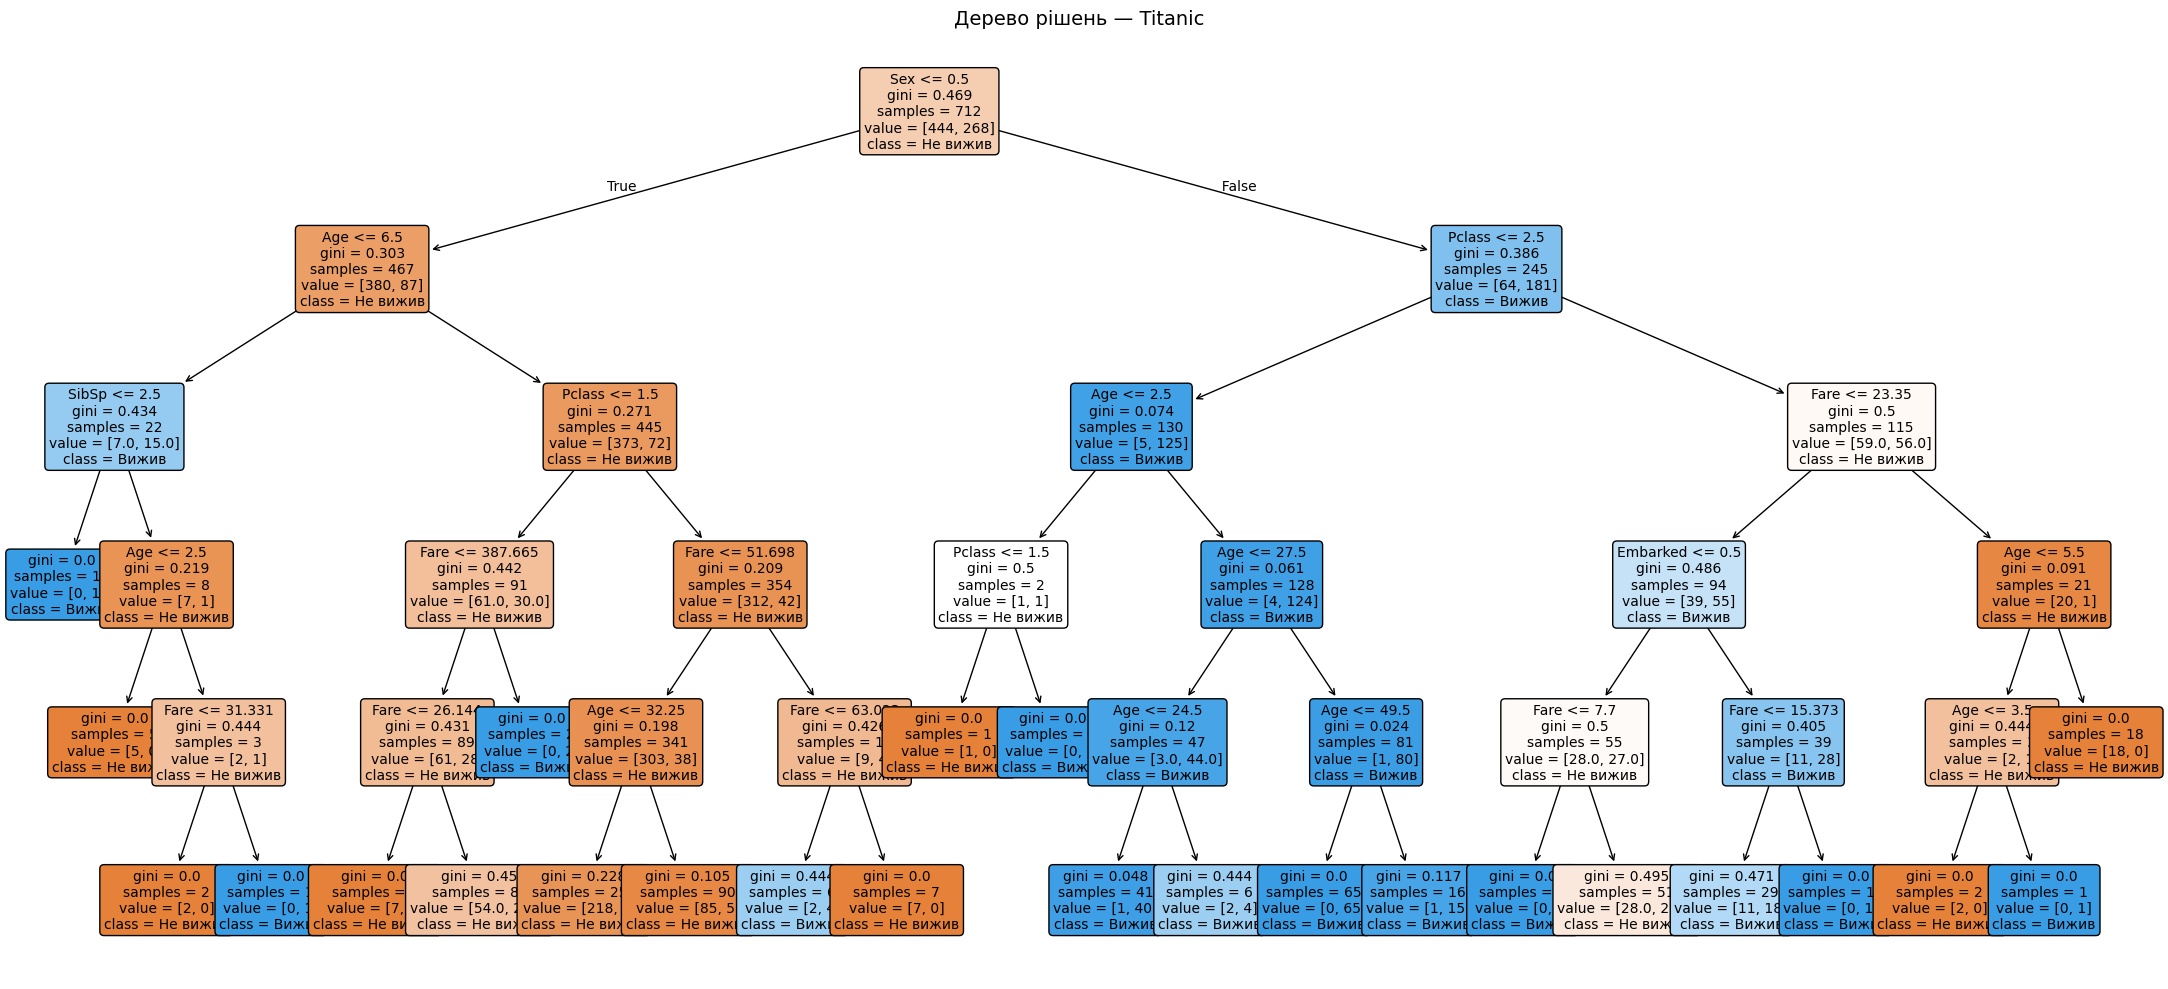

In [12]:
plt.figure(figsize=(22, 10))
plot_tree(
    model,
    feature_names=features,
    class_names=['Не вижив', 'Вижив'],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Дерево рішень — Titanic", fontsize=14)
plt.tight_layout()
plt.show()